# Cement NPV summary

Run the cement Monte Carlo NPV distribution, deterministic NPV, and Monte Carlo ranking summaries. The distribution table includes the number and share of simulations with non-negative NPV (NPV >= 0) and the number with negative NPV. This notebook displays figures inline only; it does not save figures or CSV files.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from cement.cement_npv_deterministic import calculate_deterministic_cement_results
from cement.cement_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_cement_results,
)
from cement.cement_npv_summary_figures import (
    CEMENT_NPV_SCALE_OPTIONS,
    CEMENT_TECHNOLOGY_LABELS,
    calculate_cement_npv_rankings_from_results,
)
from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_average_rank_bars, plot_mean_npv_technology_bars


## Settings

In [2]:
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE
TECHNOLOGIES = tuple(CEMENT_TECHNOLOGY_LABELS)
NPV_SCALE = "MEUR"  # "MEUR" or "EUR/t"

if NPV_SCALE not in CEMENT_NPV_SCALE_OPTIONS:
    raise ValueError(f"Unknown NPV_SCALE: {NPV_SCALE!r}")

NPV_CONFIG = CEMENT_NPV_SCALE_OPTIONS[NPV_SCALE]
NPV_METRIC_COLUMN = str(NPV_CONFIG["metric_column"])
NPV_SCALE_FACTOR = float(NPV_CONFIG["scale"])
NPV_SUMMARY_COLUMN = str(NPV_CONFIG["summary_column"])
NPV_AXIS_LABEL = str(NPV_CONFIG["axis_label"])
NPV_RANKING_LABEL = str(NPV_CONFIG["ranking_label"])

pd.options.display.float_format = "{:,.3f}".format


## Monte Carlo NPV distribution

,label,technology_type,npv_m_eur,median,p05,p95,non_negative_npv_count,negative_npv_count,non_negative_npv_share
7,CCS,retrofit,500.191,513.966,169.806,781.132,99662,338,0.997
8,Process heat integration,retrofit,475.671,475.754,398.794,552.731,100000,0,1.000
6,Waste heat recovery,retrofit,471.125,472.067,404.712,533.966,100000,0,1.000
3,Clinker substitution,retrofit,469.793,469.601,388.526,551.658,100000,0,1.000
5,Efficiency improvement,retrofit,448.622,449.020,376.242,519.284,100000,0,1.000
4,Alternative fuels,retrofit,440.919,441.205,322.097,558.970,100000,0,1.000
0,BAU,absolute,435.951,435.816,363.116,509.064,100000,0,1.000
1,Electrification,absolute,"-1,116.067","-1,141.268","-1,684.497",-464.876,5,99995,0.000
2,Electrolysis,absolute,"-4,082.973","-3,981.859","-6,298.700","-2,158.569",0,100000,0.000


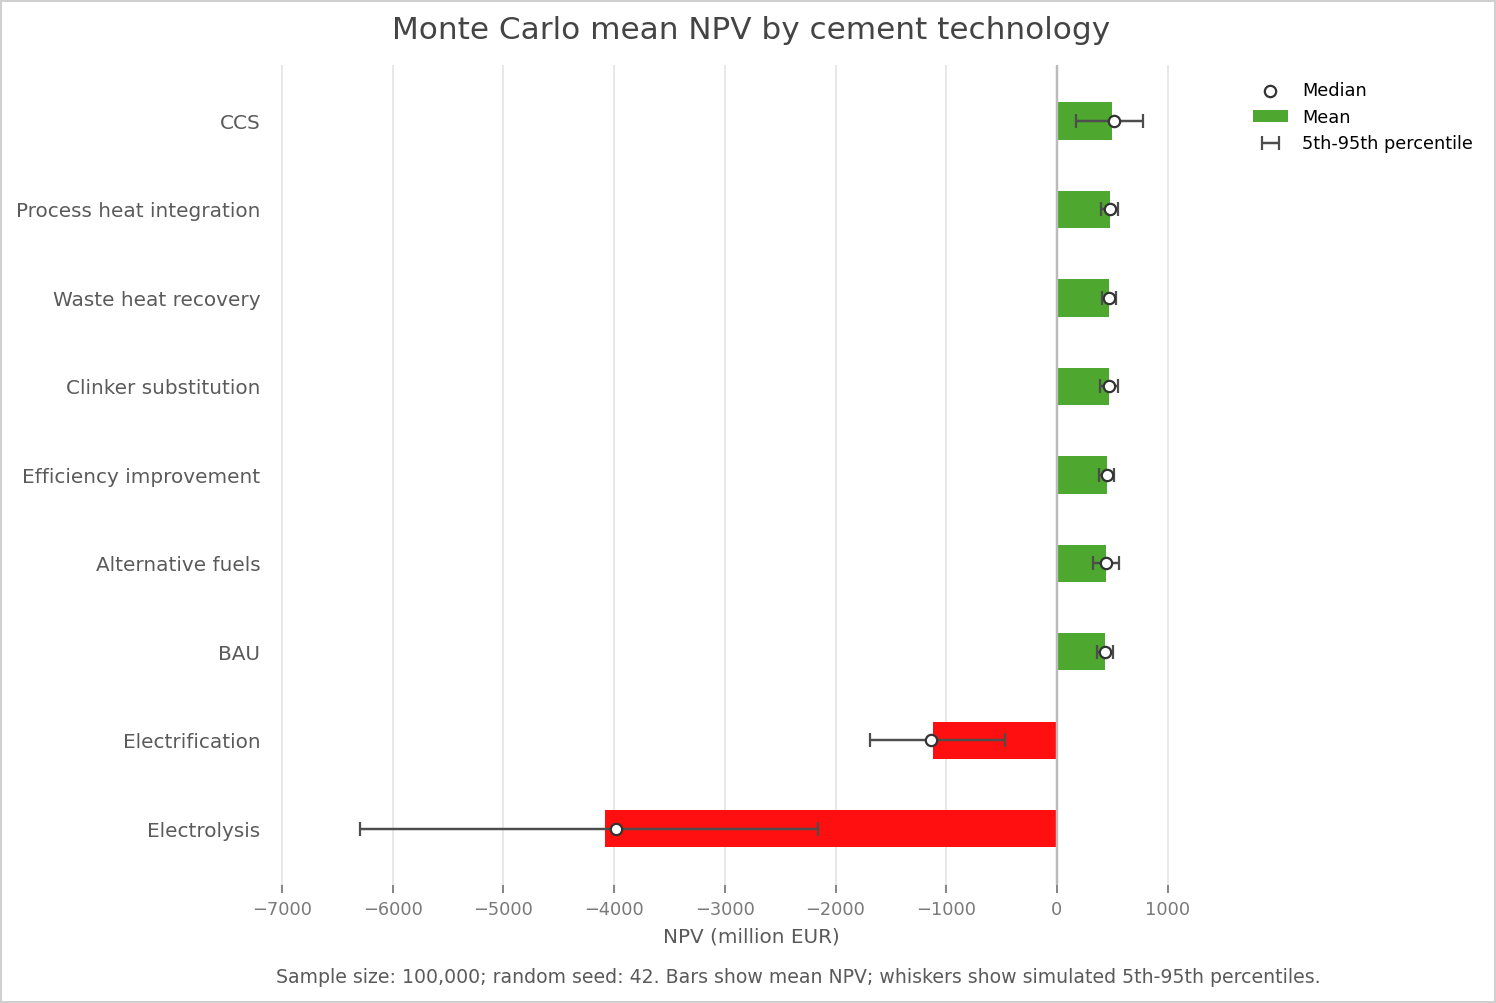

In [3]:
monte_carlo_results = simulate_cement_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=TECHNOLOGIES,
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)

mc_summary_rows = []
for technology, results in monte_carlo_results.items():
    values = np.asarray(results[NPV_METRIC_COLUMN], dtype=float) / NPV_SCALE_FACTOR
    mc_summary_rows.append(
        {
            "label": CEMENT_TECHNOLOGY_LABELS.get(technology, technology),
            "technology_type": str(np.asarray(results["technology_type"])[0]),
            NPV_SUMMARY_COLUMN: values.mean(),
            "median": np.median(values),
            "p05": np.percentile(values, 5),
            "p95": np.percentile(values, 95),
            **summarize_metric_signs(values),
        }
    )
mc_summary = pd.DataFrame(mc_summary_rows).sort_values(NPV_SUMMARY_COLUMN, ascending=False)
mc_summary_by_label = mc_summary.set_index("label")

display(mc_summary)
plot_mean_npv_technology_bars(
    values_million_eur=mc_summary_by_label[NPV_SUMMARY_COLUMN].to_dict(),
    output_path=None,
    title=f"Monte Carlo mean {NPV_RANKING_LABEL} by cement technology",
    median_values_million_eur=mc_summary_by_label["median"].to_dict(),
    lower_values_million_eur=mc_summary_by_label["p05"].to_dict(),
    upper_values_million_eur=mc_summary_by_label["p95"].to_dict(),
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    x_axis_label=NPV_AXIS_LABEL,
)
plt.show()


## Deterministic NPV

,label,technology_type,npv_m_eur
7,CCS,retrofit,529.512
8,Process heat integration,retrofit,510.910
6,Waste heat recovery,retrofit,505.769
3,Clinker substitution,retrofit,503.056
5,Efficiency improvement,retrofit,485.016
4,Alternative fuels,retrofit,480.287
0,BAU,absolute,474.262
1,Electrification,absolute,"-1,088.032"
2,Electrolysis,absolute,"-4,020.192"


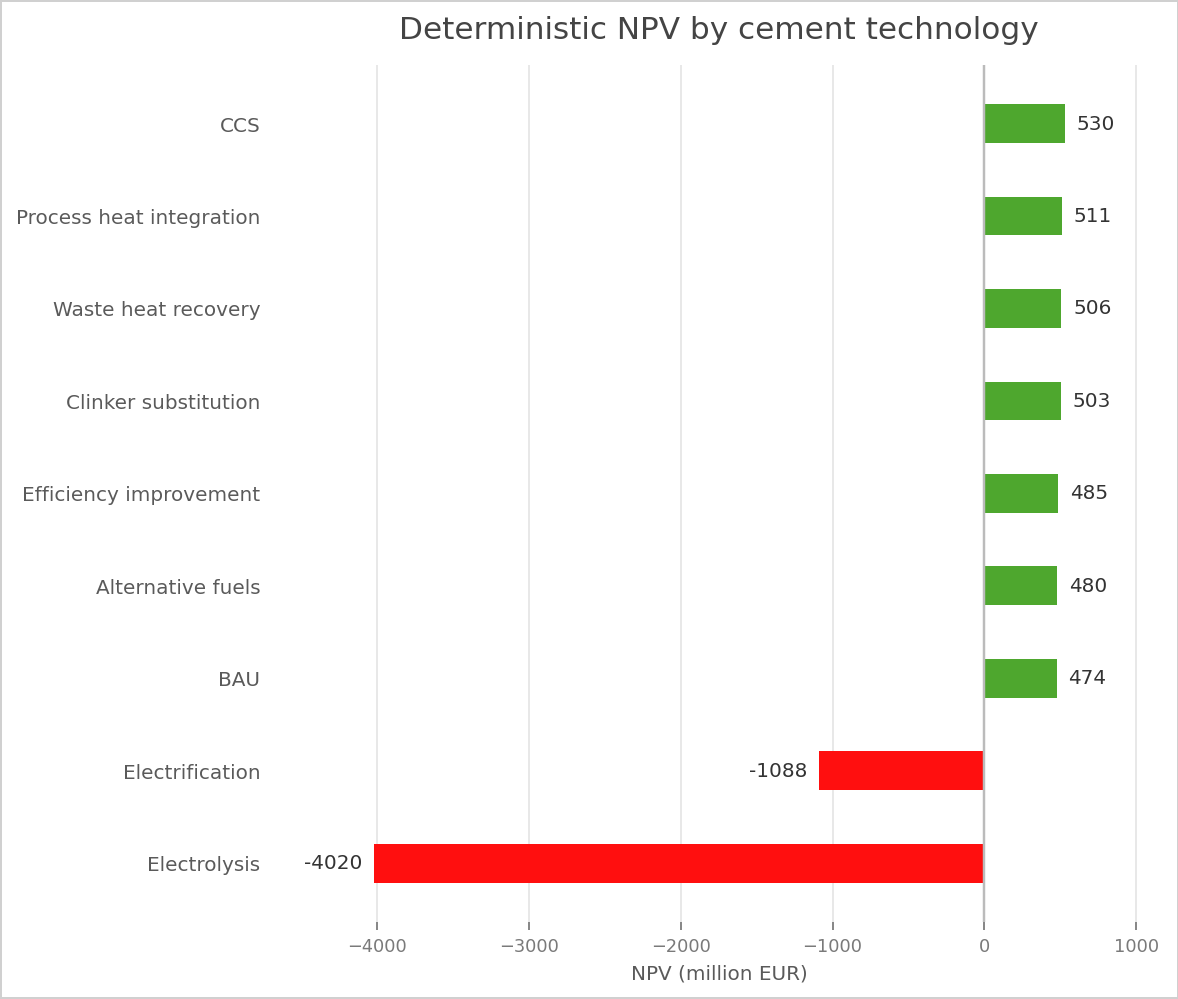

In [4]:
deterministic_results = calculate_deterministic_cement_results(technologies=TECHNOLOGIES)
det_summary_rows = []
for technology, results in deterministic_results.items():
    det_summary_rows.append(
        {
            "label": CEMENT_TECHNOLOGY_LABELS.get(technology, technology),
            "technology_type": str(np.asarray(results["technology_type"])[0]),
            NPV_SUMMARY_COLUMN: float(np.asarray(results[NPV_METRIC_COLUMN]).item()) / NPV_SCALE_FACTOR,
        }
    )
det_summary = pd.DataFrame(det_summary_rows).sort_values(NPV_SUMMARY_COLUMN, ascending=False)

display(det_summary)
plot_mean_npv_technology_bars(
    values_million_eur=det_summary.set_index("label")[NPV_SUMMARY_COLUMN].to_dict(),
    output_path=None,
    title=f"Deterministic {NPV_RANKING_LABEL} by cement technology",
    x_axis_label=NPV_AXIS_LABEL,
)
plt.show()


## Monte Carlo NPV ranking

,Technology,Average rank,Probability rank 1,Probability top 3,Simulations
0,Process heat integration,2.876,0.134,0.702,100000
1,Waste heat recovery,3.095,0.097,0.629,100000
2,Clinker substitution,3.373,0.119,0.567,100000
3,CCS,3.441,0.517,0.581,100000
4,Alternative fuels,4.618,0.128,0.364,100000
5,Efficiency improvement,4.752,0.005,0.152,100000
6,BAU,5.845,0.000,0.004,100000
7,Electrification,8.000,0.000,0.000,100000
8,Electrolysis,9.000,0.000,0.000,100000


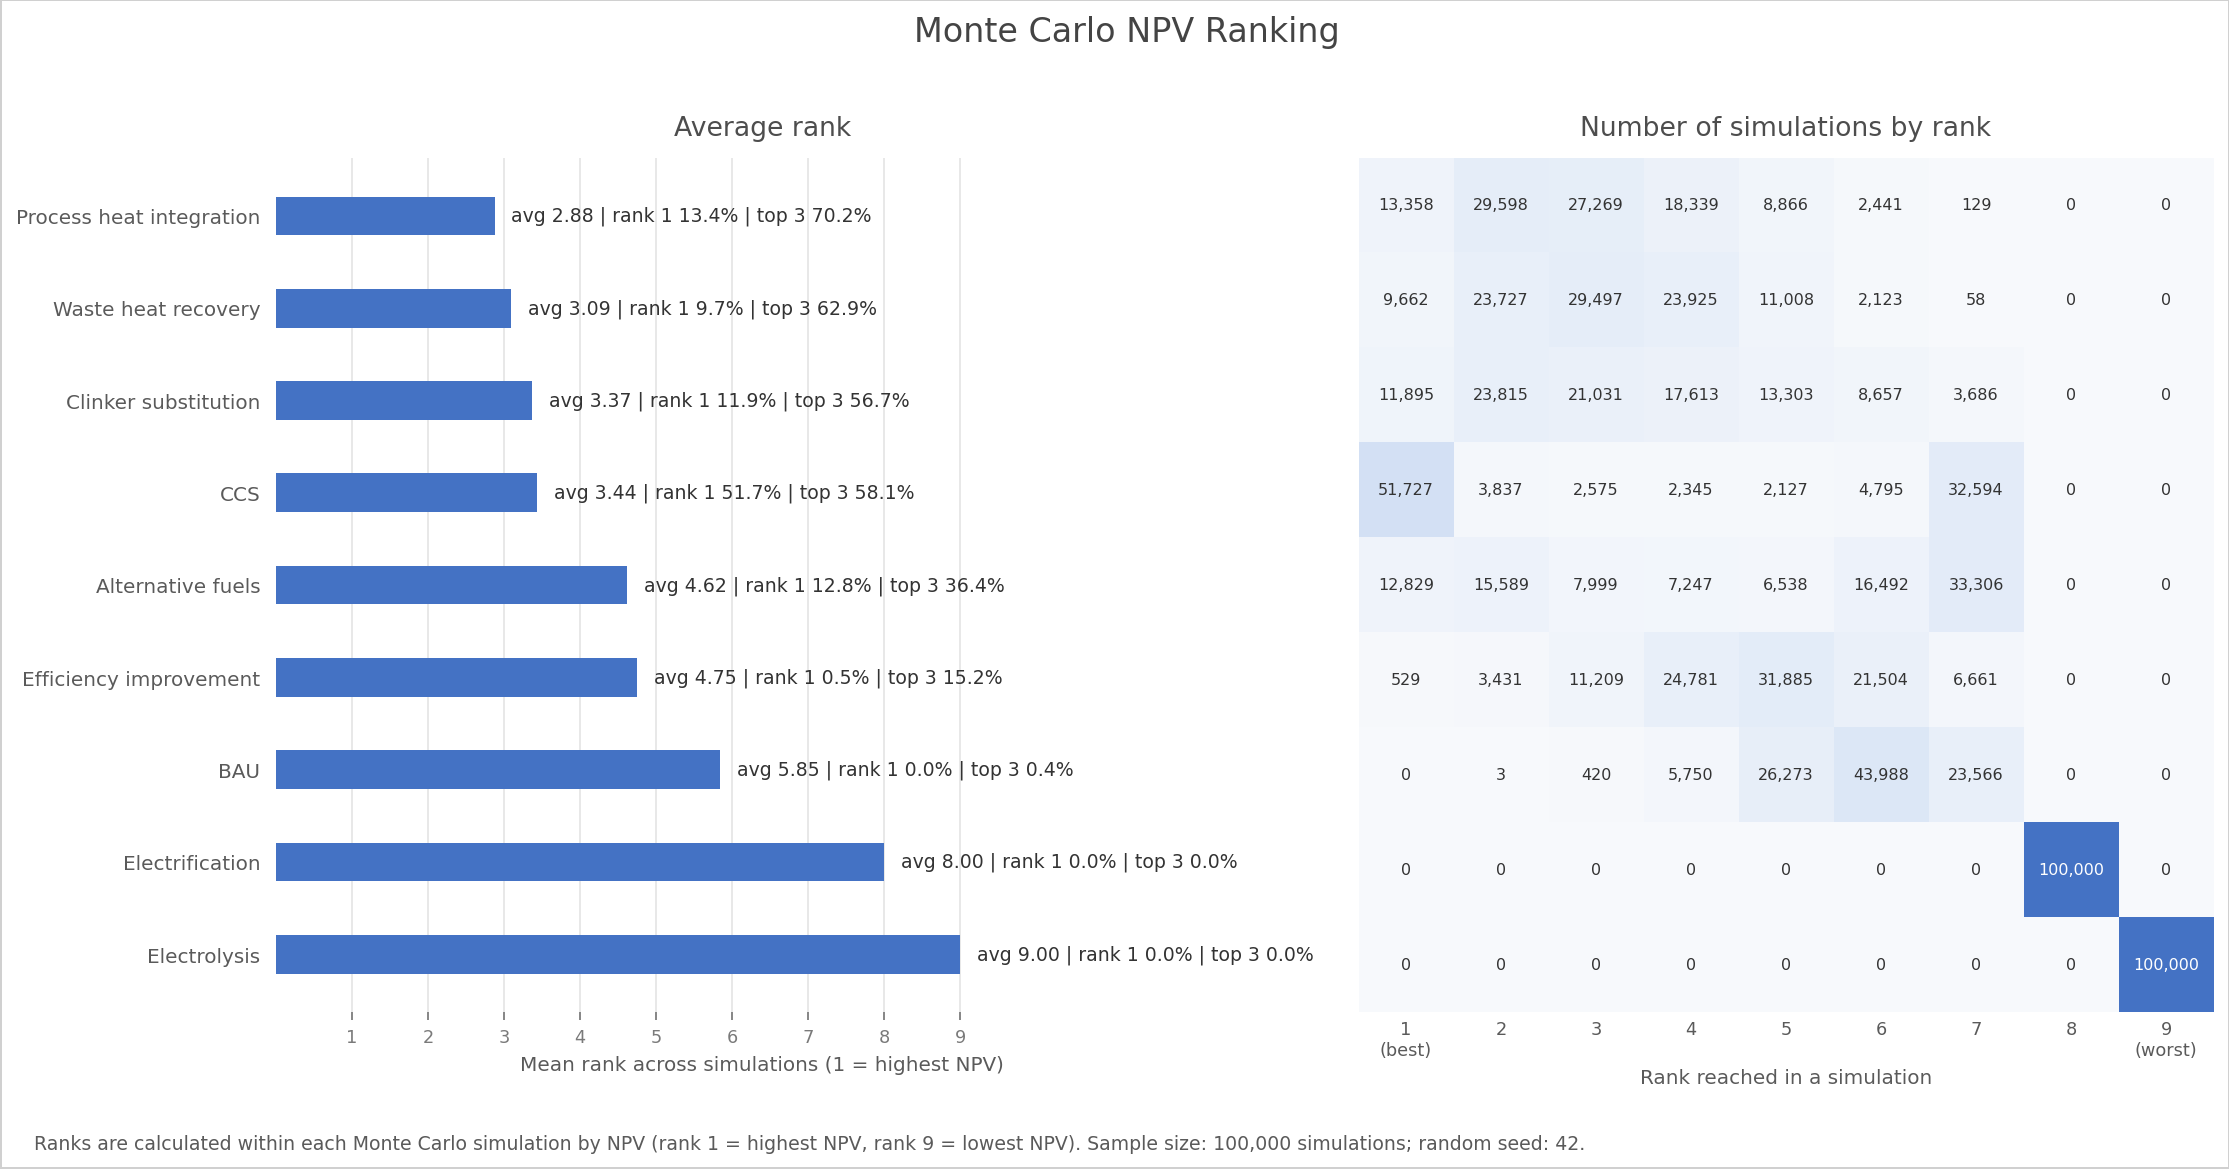

In [5]:
ranking_raw, ranking_summary = calculate_cement_npv_rankings_from_results(
    results=monte_carlo_results,
    sector_name="Cement",
    npv_scale=NPV_SCALE,
)

ranking_summary_for_plot = ranking_summary.assign(
    display_label=ranking_summary["technology"].map(CEMENT_TECHNOLOGY_LABELS).fillna(ranking_summary["technology"])
)
rank_table = (
    ranking_summary_for_plot.rename(columns={"display_label": "Technology"})
    .loc[:, ["Technology", "average_rank", "probability_rank_1", "probability_top_3", "n_simulations"]]
    .rename(
        columns={
            "average_rank": "Average rank",
            "probability_rank_1": "Probability rank 1",
            "probability_top_3": "Probability top 3",
            "n_simulations": "Simulations",
        }
    )
)
display(rank_table)
plot_average_rank_bars(
    ranking_summary=ranking_summary_for_plot,
    output_path=None,
    title=f"Monte Carlo {NPV_RANKING_LABEL} Ranking",
    random_seed=RANDOM_SEED,
)
plt.show()
